<h2>Matplotlib: основы визуализации данных в Python</h2>

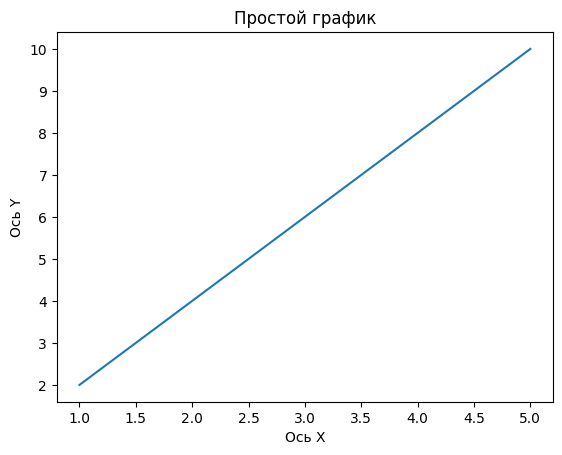

In [3]:
import matplotlib.pyplot as plt

# Создаем данные
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

# Создаем график
plt.plot(x, y)

# Добавляем заголовки
plt.title("Простой график")
plt.xlabel("Ось X")
plt.ylabel("Ось Y")

# Показываем график
plt.show()

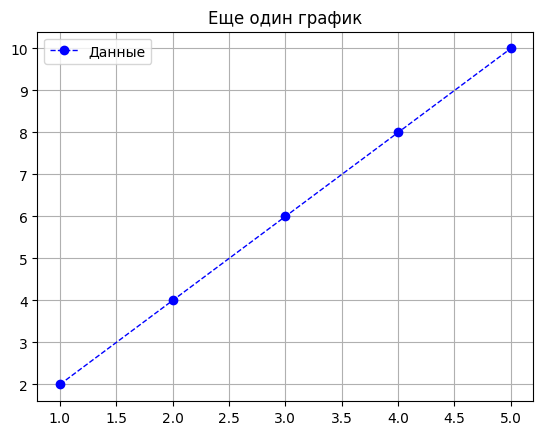

In [13]:
# linestyles: '-', '--', '-.', ':'
# markers: 'o', 's', 'D', '^', 'v', '*', 'x', 'X', 'p', 'h'

plt.plot(x, y, color='blue', linestyle='--', linewidth=1, marker='o', label='Данные')
plt.legend()
plt.title("Еще один график")
plt.grid(True)
plt.show()

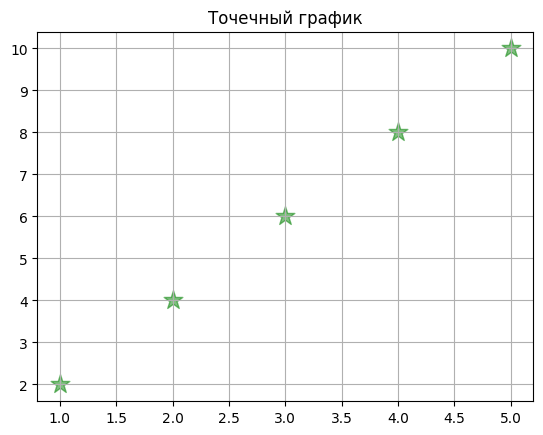

In [17]:
plt.scatter(x, y, c='green', marker='*', s=200, alpha=0.5)
plt.grid()
plt.title("Точечный график")
plt.show()

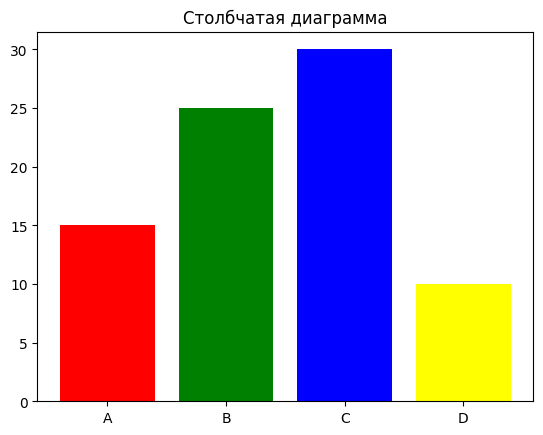

In [29]:
categories = ['A', 'B', 'C', 'D']
values = [15, 25, 30, 10]
plt.bar(categories, values, color=['red', 'green', 'blue', 'yellow'])
plt.title("Столбчатая диаграмма")
plt.show()

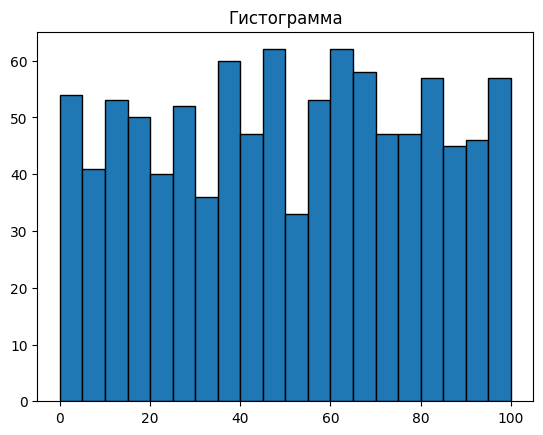

In [37]:
import random
data = [random.randint(0, 100) for x in range(1000)]

plt.hist(data, bins=20, edgecolor='black')
plt.title("Гистограмма")
plt.show()

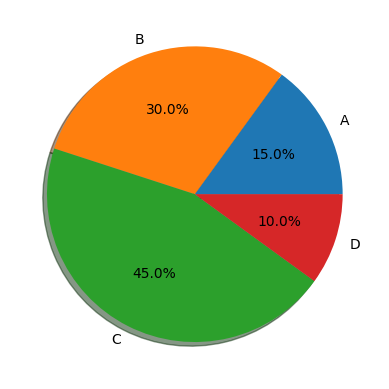

In [24]:
sizes = [15, 30, 45, 10]
labels = ['A', 'B', 'C', 'D']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True)
# autopct: '%1.1f%%', '%d%%', '%.2ff%%'

plt.plot("Круговая диаграмма")
plt.show()

<h2>Работа с несколькими графиками</h2>

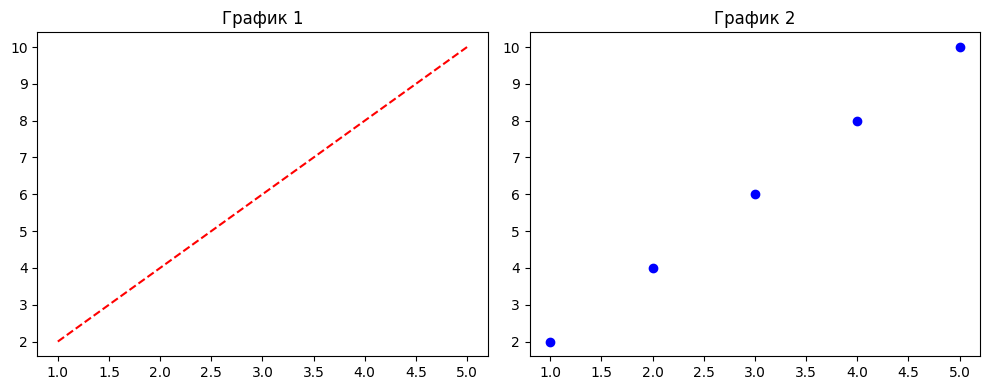

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) # аргументы - число строк, число колонок

ax1.plot(x, y, 'r--')
ax1.set_title('График 1')

ax2.scatter(x, y, c='b')
ax2.set_title('График 2')

plt.tight_layout()
plt.show()

In [38]:
print(plt.style.available)  # Показать доступные стили

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


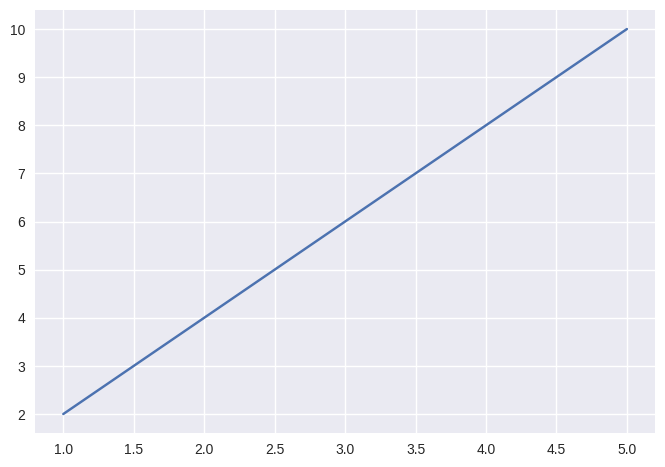

In [40]:
plt.style.use('seaborn-v0_8')  # Применить стиль

# Теперь все графики будут в стиле seaborn-v0_8
plt.plot(x, y)
plt.show()

Сохранение в файл:

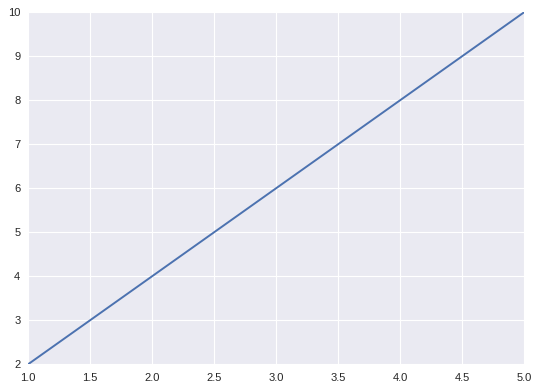

In [ ]:
plt.plot(x, y)
plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')

Построим графики по данным, полученным при парсинге истории канала ОКСФ.

In [ ]:
!wget https://phonetics-spbu.github.io/courses/python_mag_1/files/oksf_stat.csv

Нарисуем график количества лайков под постами:

In [42]:
import csv

with open("oksf_stat.csv", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    data = list(reader)
    header = reader.fieldnames

In [43]:
header

['дата', 'время', 'длина сообщения', 'есть ли картинка', 'количество реакций']

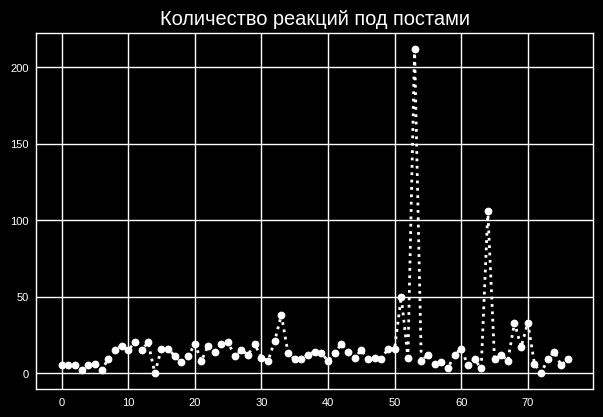

In [60]:
reactions_number = [int(row['количество реакций']) for row in data if int(row['длина сообщения']) > 0]

plt.style.use('dark_background')

plt.plot(reactions_number, color='white', linestyle=':', linewidth=2, marker='o')
plt.title("Количество реакций под постами")
plt.grid(True)
plt.show()

Построим столбчатую диаграмму: посты с картинками, просто картинки, технические сообщения (нет ни картинки, ни текста)

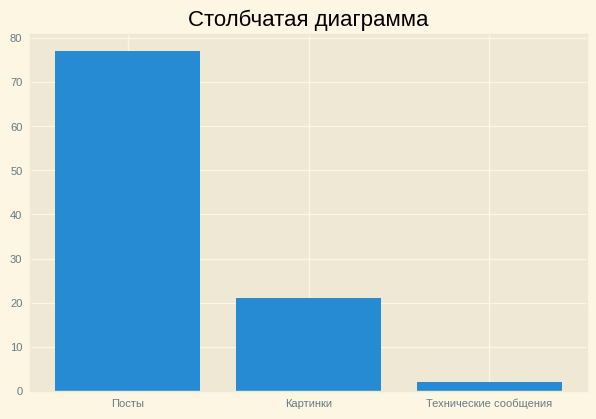

In [79]:
categories = ['Посты', 'Картинки', 'Технические сообщения']

posts_num = len([row for row in data if int(row['длина сообщения']) > 0])
pics_num = len([row for row in data if int(row['длина сообщения']) == 0 and row['есть ли картинка'] == "True"])
tech_num = len([row for row in data if (int(row['длина сообщения']) == 0 and row['есть ли картинка'] == "False")])

values = [posts_num, pics_num, tech_num]

plt.style.use('Solarize_Light2')
plt.bar(categories, values)
plt.title("Столбчатая диаграмма", color="black")
plt.show()

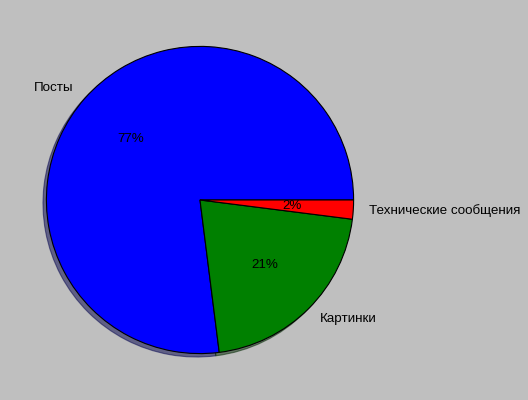

In [83]:
sizes = [posts_num, pics_num, tech_num]
labels = ['Посты', 'Картинки', 'Технические сообщения']
plt.pie(sizes, labels=labels, autopct='%d%%', shadow=True)

plt.style.use("seaborn-v0_8-dark")
plt.plot("Круговая диаграмма")
plt.show()

Построим точечную диаграмму длина сообщения - количество реакций:

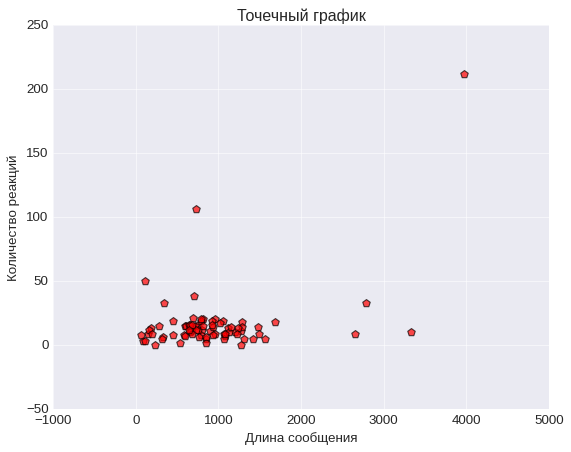

In [87]:
msg_length = [int(row['длина сообщения']) for row in data if int(row['длина сообщения']) > 0]

plt.scatter(msg_length, reactions_number, c='red', marker='p', s=50, alpha=0.7)
plt.xlabel("Длина сообщения")
plt.ylabel("Количество реакций")
plt.grid()
plt.title("Точечный график")
plt.show()

In [ ]:
!wget https://phonetics-spbu.github.io/courses/python_mag_1/files/Бармаглот.txt

Задача. Прочитайте текстовый файл Бармаглот.txt. Посчитайте длину каждого слова и постройте столбчатую диаграмму.

Задача. Подсчитайте частоту каждого символа (кроме пробелов) и постройте круговую диаграмму топ-3 символов.

Задача. Посчитайте количество гласных и согласных букв (без учета регистра) и постройте столбчатую диаграмму.

Задача. Постройте график зависимости длины предложения от его номера. Предложения в тексте могут заканчиваться на точку или восклицательный знак.

Задача. Постройте точечный график зависимости длины предложения от средней длины слова в нем.